
# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay, RocCurveDisplay
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Breast Cancer Wisconsin** contiene 569 muestras de biopsias de mama con 30 features numéricas computadas a partir de imágenes digitalizadas de aspiración con aguja fina (FNA). El target es binario: **maligno (0)** o **benigno (1)**.

In [70]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'maligno', 1: 'benigno'})

print(f'Dataset: {df.shape[0]} muestras, {df.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df['diagnosis'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} benigno, {1-df["target"].mean():.1%} maligno')

Dataset: 569 muestras, 30 features

Distribución de clases:
diagnosis
benigno    357
maligno    212
Name: count, dtype: int64

Proporción: 62.7% benigno, 37.3% maligno


In [71]:
df.describe().round(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


---
## 3. Análisis exploratorio orientado a clasificación

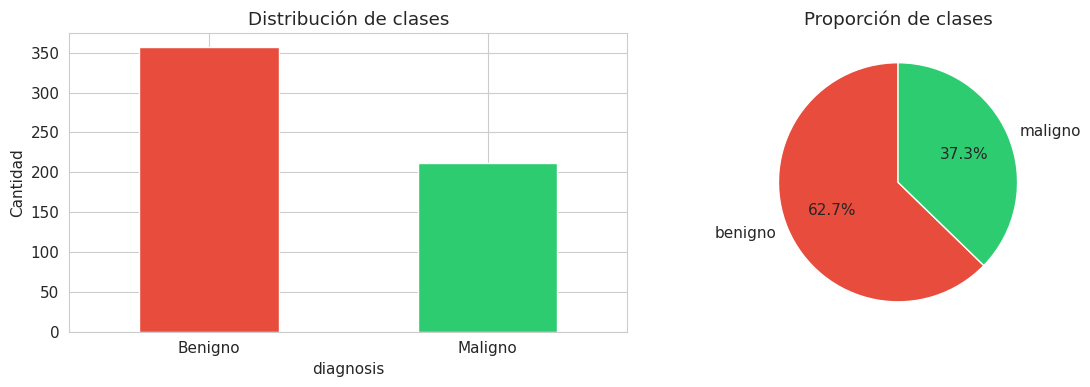

In [72]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
colors = ['#e74c3c', '#2ecc71']
df['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Benigno', 'Maligno'], rotation=0)

# Pie chart
df['diagnosis'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

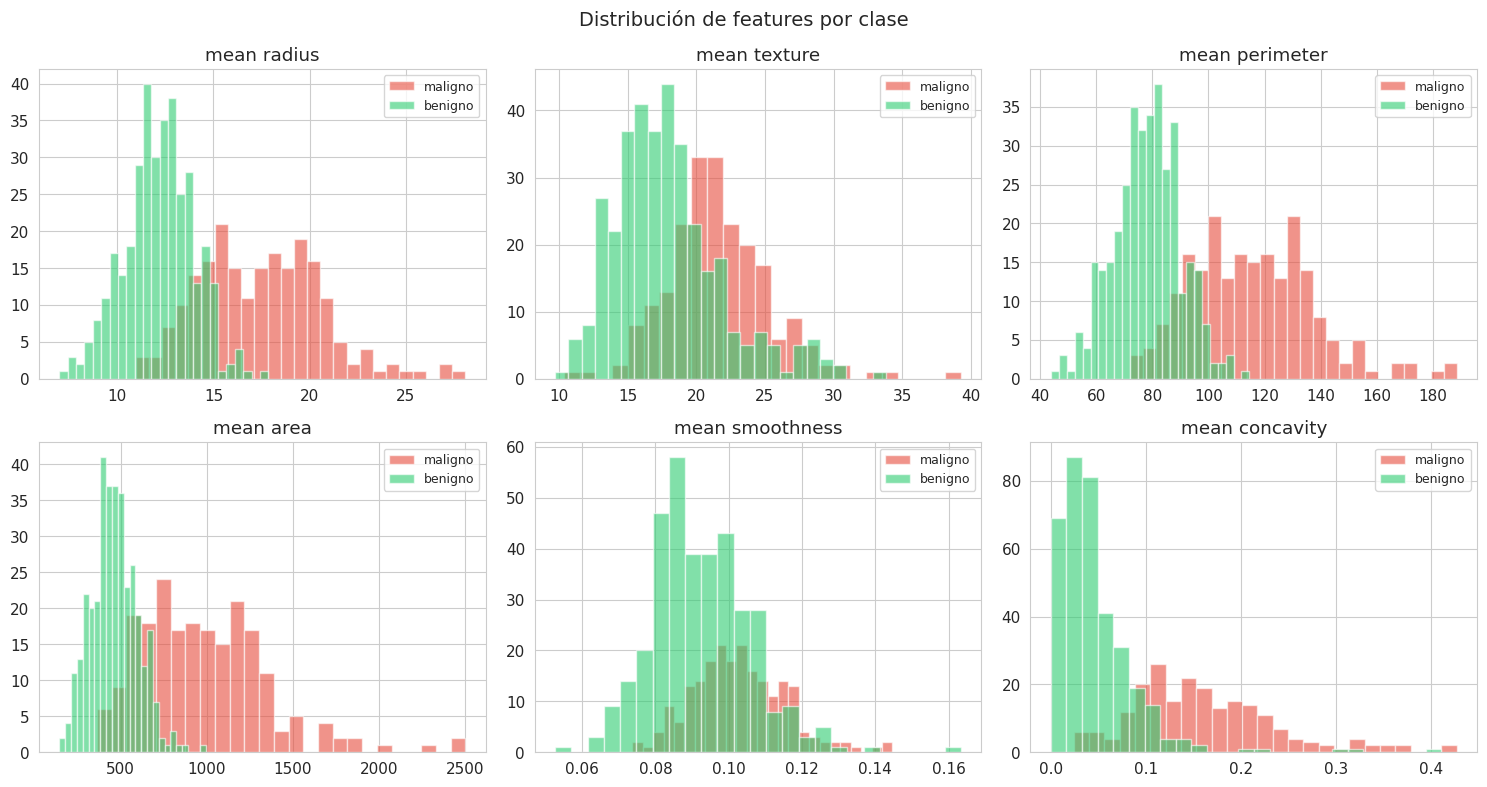

In [73]:
# 3.2  Distribución de features clave por clase
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='maligno' if label == 0 else 'benigno')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase', fontsize=14)
plt.tight_layout()
plt.show()

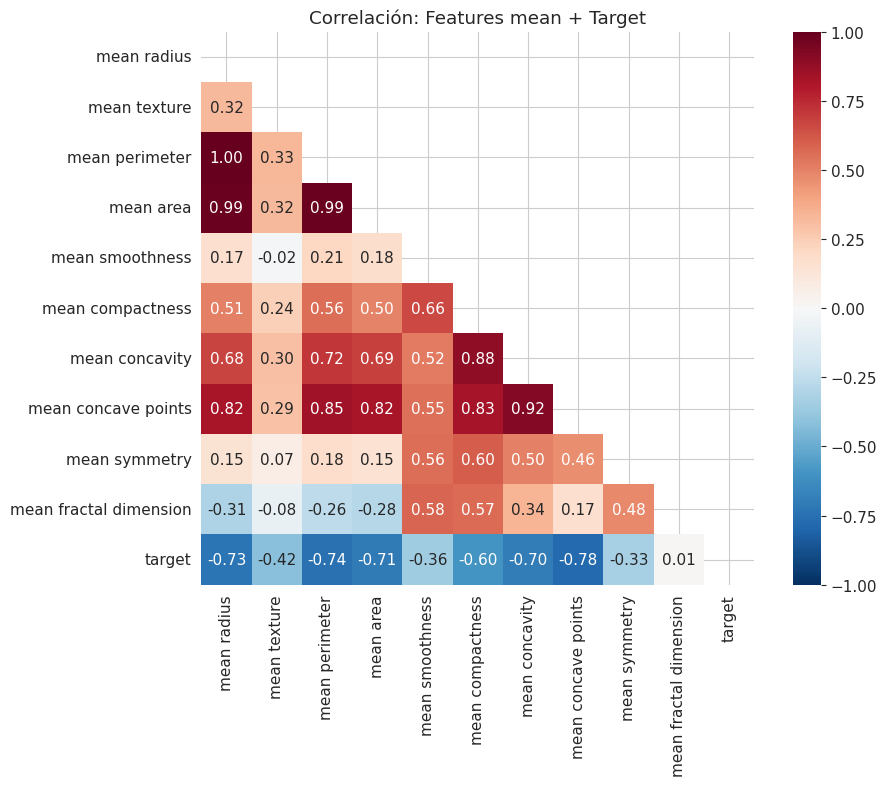

In [74]:
# 3.3  Matriz de correlación (features mean)
mean_features = [c for c in df.columns if 'mean' in c]
plt.figure(figsize=(10, 8))
corr = df[mean_features + ['target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: Features mean + Target')
plt.tight_layout()
plt.show()

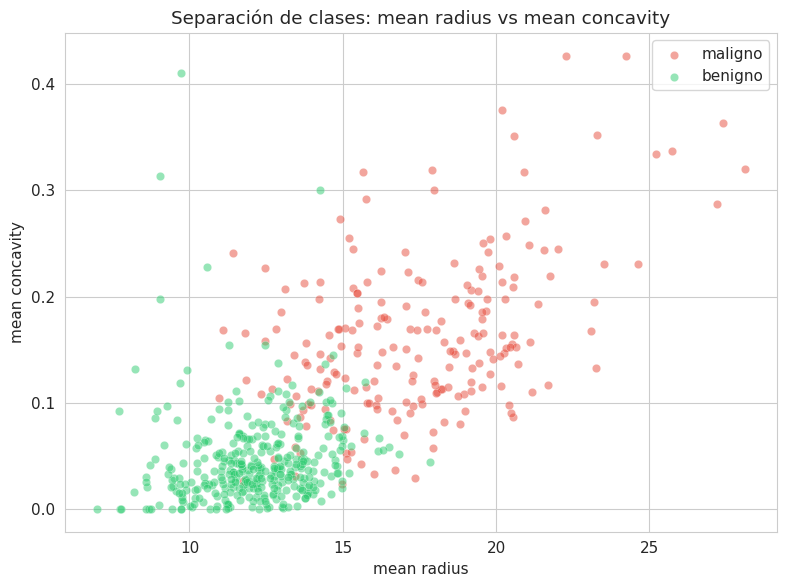

In [75]:
# 3.4  Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, ['maligno', 'benigno']):
    mask = df['target'] == label
    ax.scatter(df.loc[mask, 'mean radius'], df.loc[mask, 'mean concavity'],
              alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('mean radius')
ax.set_ylabel('mean concavity')
ax.set_title('Separación de clases: mean radius vs mean concavity')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [76]:
X = df[data.feature_names].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} benigno')
print(f'Proporción en test:  {y_test.mean():.1%} benigno')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 455 muestras
Test:          114 muestras

Proporción en train: 62.6% benigno
Proporción en test:  63.2% benigno


### Funciones auxiliares para evaluación de clasificadores

In [77]:
def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo',
                     class_names=('maligno', 'benigno')):
    """Evalúa un clasificador: métricas, matriz de confusión y reporte.
    class_names=(clase_0, clase_1) permite reutilizar la función con otros datasets
    (por defecto usa las etiquetas de Breast Cancer de la sesión)."""
    y_pred = model.predict(X_te)
    neg_name, pos_name = class_names

    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1-Score':  f1_score(y_te, y_pred)
    }

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    # Matriz de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=[neg_name.capitalize(), pos_name.capitalize()],
                yticklabels=[neg_name.capitalize(), pos_name.capitalize()])
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose FP y FN
    tn, fp, fn, tp = cm.ravel()
    labels = [f'TN\n({pos_name}\ncorrecto)', f'FP\n({pos_name}→\n{neg_name})',
              f'FN\n({neg_name}→\n{pos_name})', f'TP\n({neg_name}\ncorrecto)']
    values = [tn, fp, fn, tp]
    bar_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  FN ({neg_name} no detectado): {fn}')
    print(f'  FP ({pos_name} como {neg_name}): {fp}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred,
          target_names=[neg_name, pos_name]))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    """Genera la curva ROC de un modelo."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        print(f'{model_name}: no soporta probabilidades')
        return None

    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2,
            label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()

    return roc_auc

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [78]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr["test_accuracy"].mean():.4f} ± {cv_lr["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr["test_f1"].mean():.4f} ± {cv_lr["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr["test_recall"].mean():.4f} ± {cv_lr["test_recall"].std():.4f}')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.9780 ± 0.0098
  F1-Score:  0.9825 ± 0.0078
  Recall:    0.9860 ± 0.0131


=== Regresión Logística ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


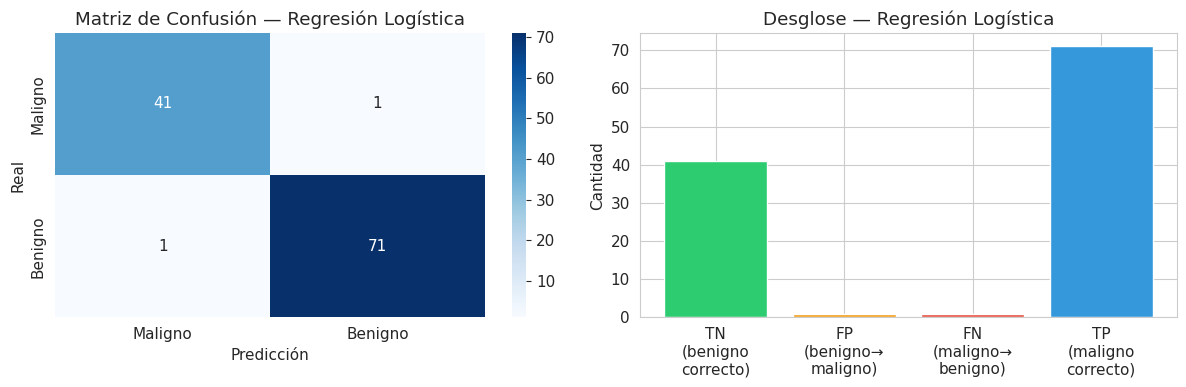


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [79]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

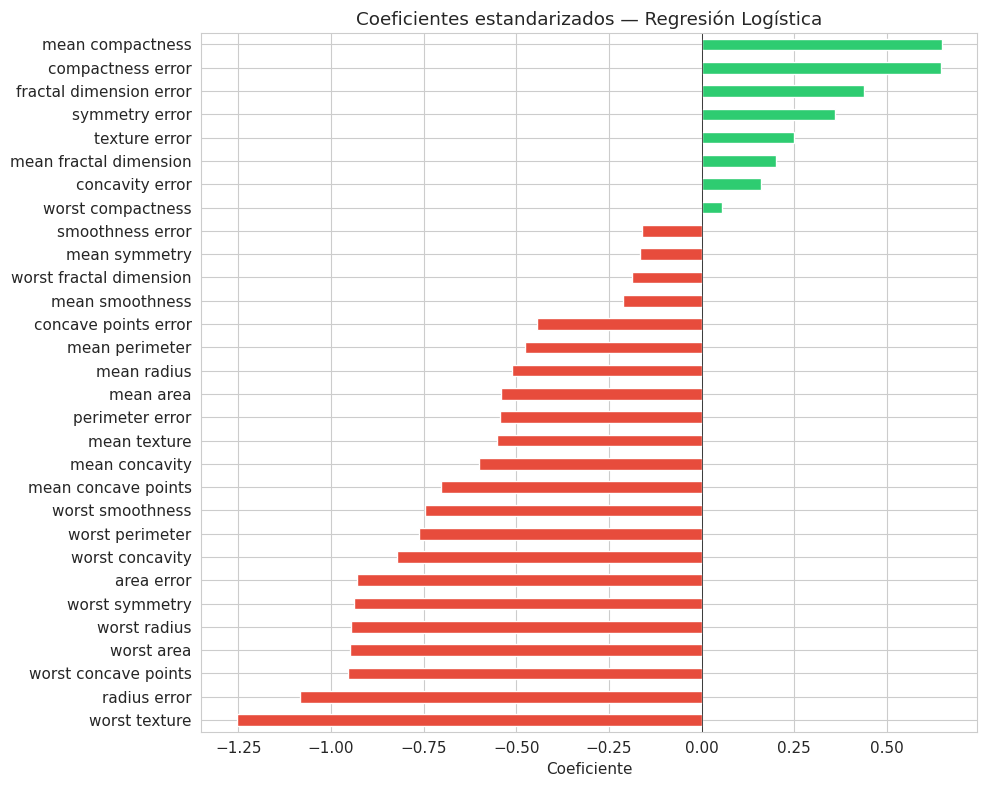

Interpretación:
  → Features que más indican MALIGNO: ['worst texture', 'radius error', 'worst concave points']
  → Features que más indican BENIGNO: ['fractal dimension error', 'compactness error', 'mean compactness']


In [80]:
# 5.3  Coeficientes estandarizados
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=data.feature_names
).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican MALIGNO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican BENIGNO: {coefs.tail(3).index.tolist()}')

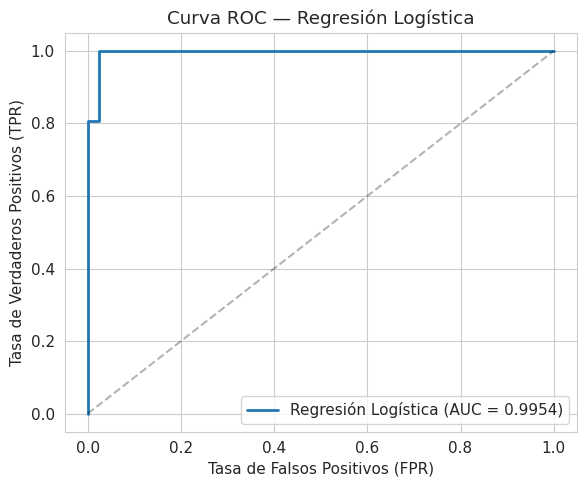

AUC: 0.9954


In [81]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [82]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1', 'recall'],
                            return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full["test_accuracy"].mean():.4f} ± {cv_dt_full["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full["test_f1"].mean():.4f} ± {cv_dt_full["test_f1"].std():.4f}')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.9165 ± 0.0179
  Test F1-Score:  0.9319 ± 0.0144

⚠ Train accuracy ~1.0 indica sobreajuste


In [83]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=['accuracy', 'f1', 'recall'],
                       return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt["test_accuracy"].mean():.4f} ± {cv_dt["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt["test_f1"].mean():.4f} ± {cv_dt["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt["test_recall"].mean():.4f} ± {cv_dt["test_recall"].std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9747
  Test Accuracy:  0.9275 ± 0.0226
  Test F1-Score:  0.9417 ± 0.0189
  Test Recall:    0.9368 ± 0.0325


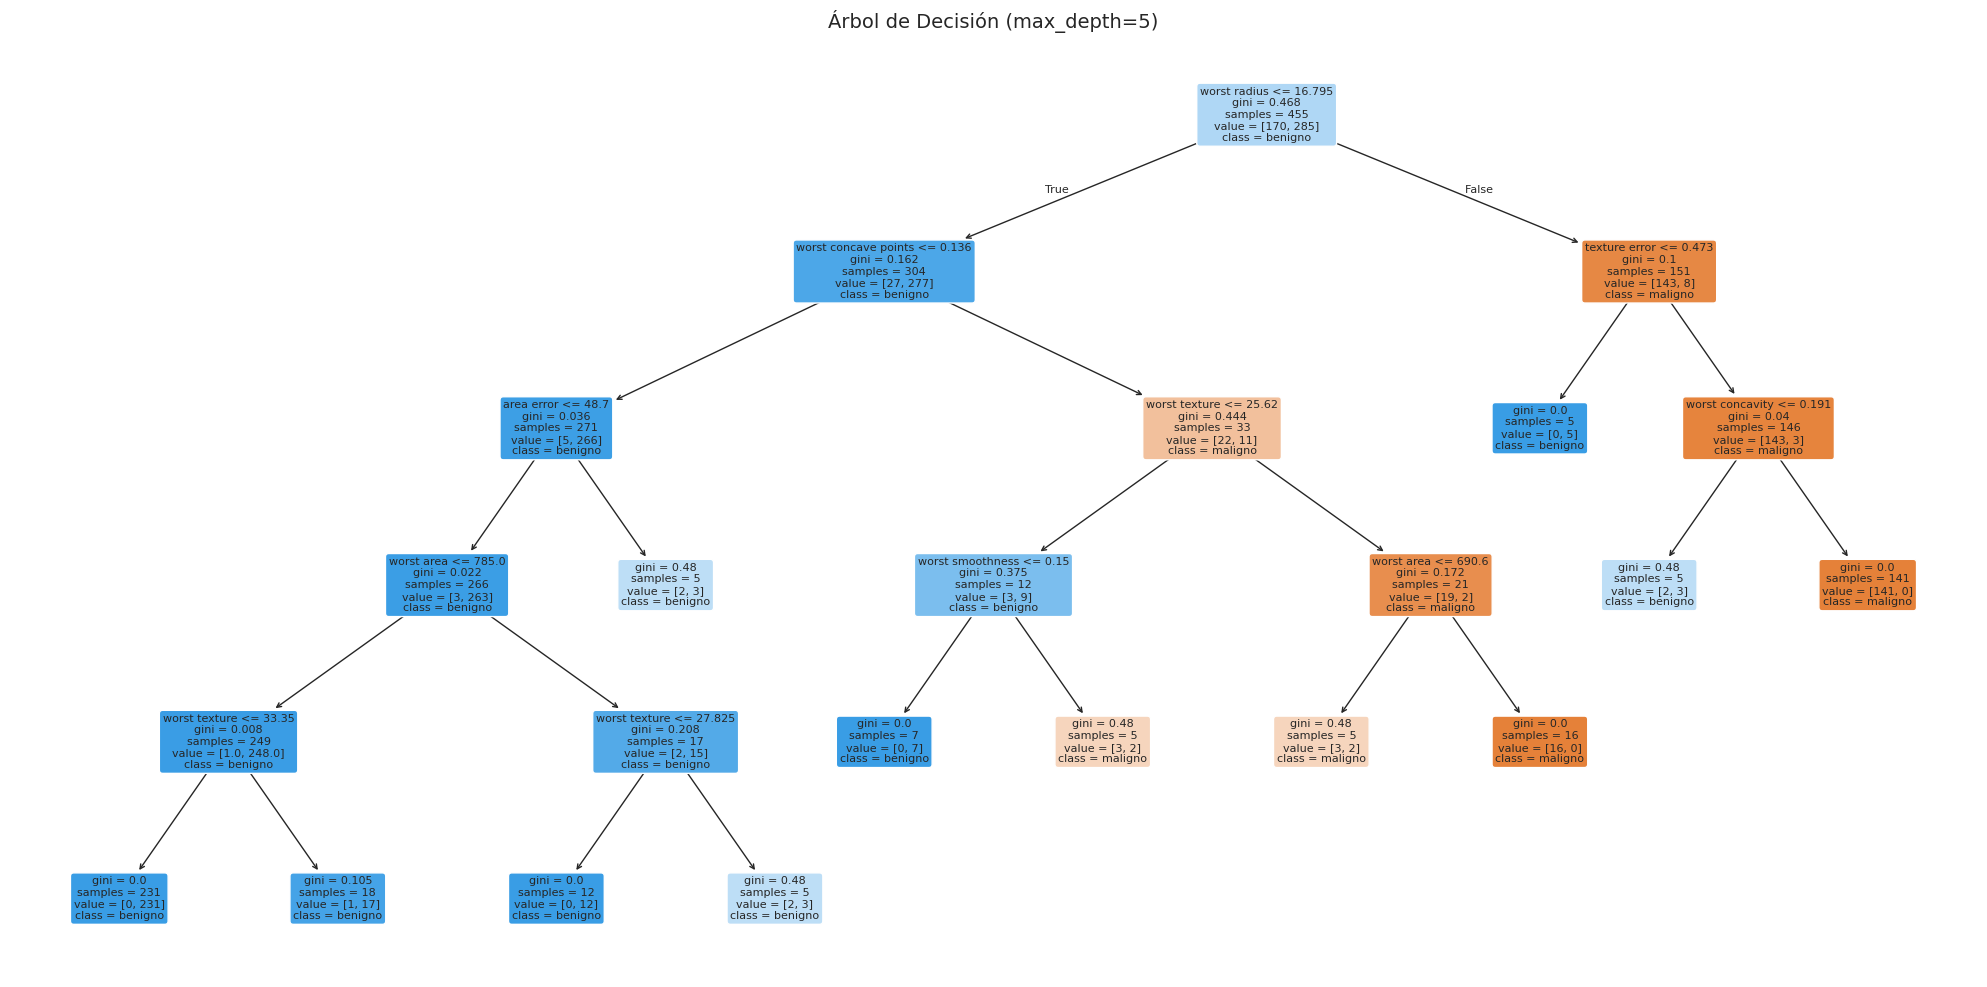

In [84]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=data.feature_names,
          class_names=['maligno', 'benigno'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.9211
  Precision: 0.9437
  Recall: 0.9306
  F1-Score: 0.9371


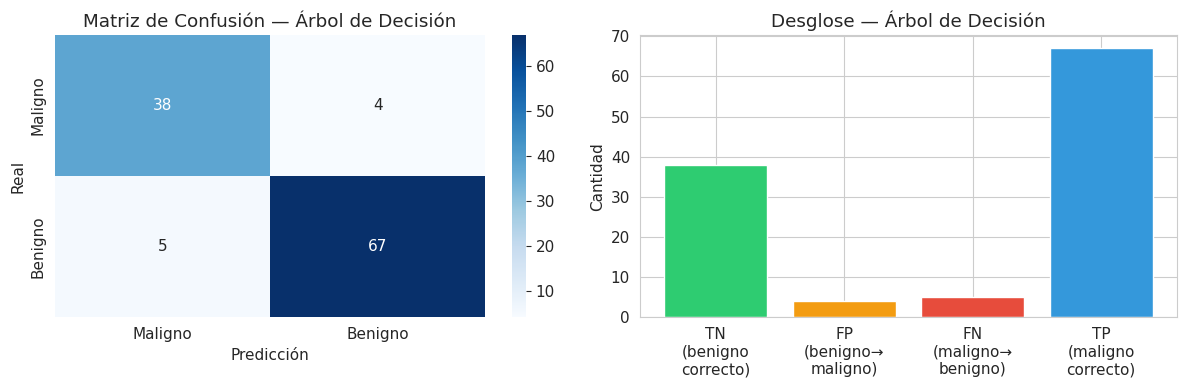


  FN (maligno no detectado): 5
  FP (benigno como maligno): 4

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.88      0.90      0.89        42
     benigno       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



In [85]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

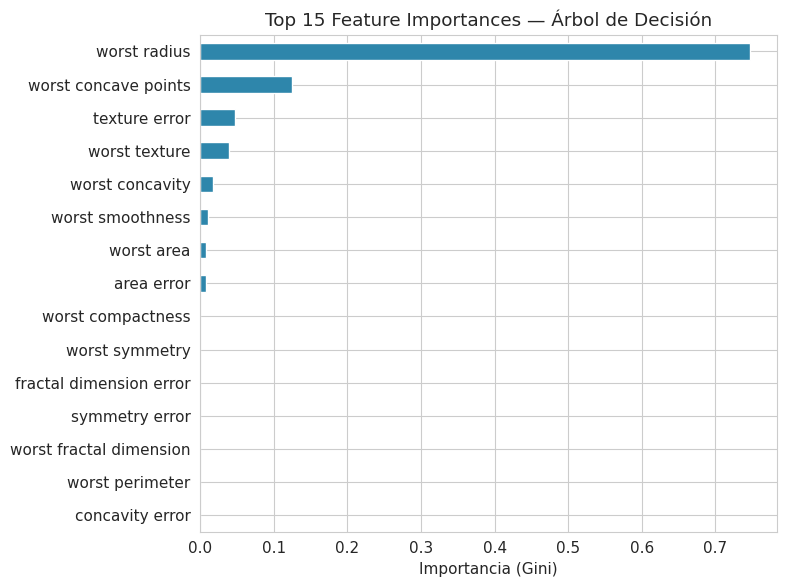

In [86]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=data.feature_names
).sort_values(ascending=True)

# Top 15
top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

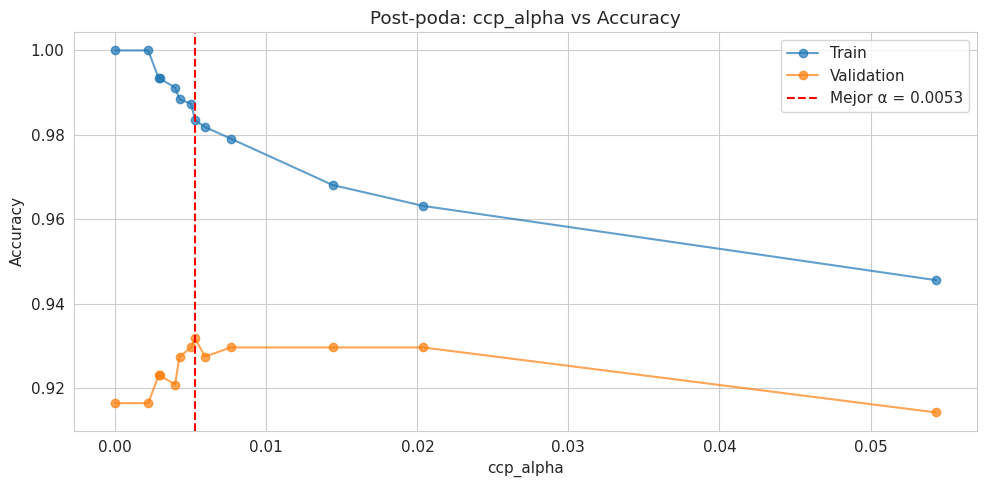

Mejor ccp_alpha: 0.005275


In [87]:
# 6.6  Post-poda con ccp_alpha
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [88]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm["test_accuracy"].mean():.4f} ± {cv_svm["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm["test_f1"].mean():.4f} ± {cv_svm["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm["test_recall"].mean():.4f} ± {cv_svm["test_recall"].std():.4f}')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.9692 ± 0.0146
  F1-Score:  0.9756 ± 0.0113
  Recall:    0.9789 ± 0.0131


=== SVM (RBF) ===
  Accuracy: 0.9825
  Precision: 0.9861
  Recall: 0.9861
  F1-Score: 0.9861


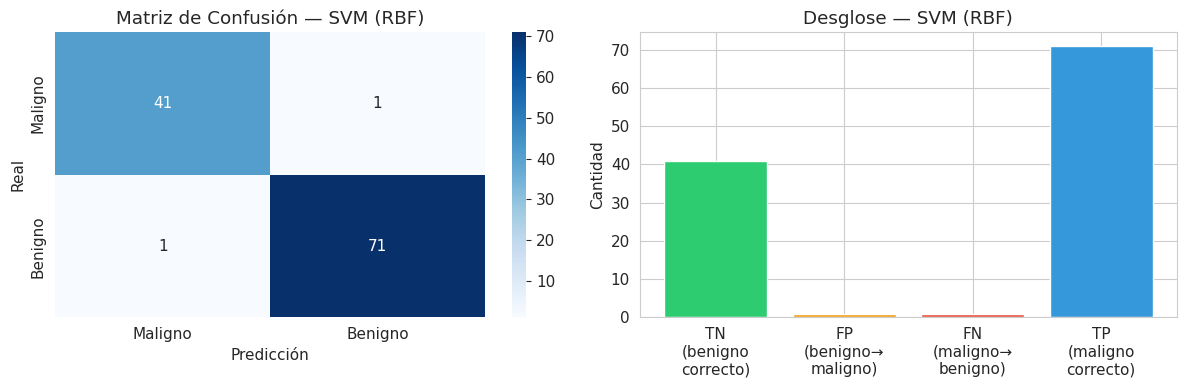


  FN (maligno no detectado): 1
  FP (benigno como maligno): 1

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [89]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.9648
  Kernel rbf     : Accuracy = 0.9692
  Kernel poly    : Accuracy = 0.8967


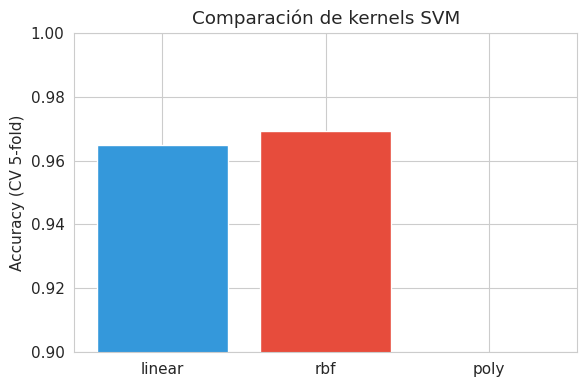

In [90]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(0.9, 1.0)
plt.tight_layout()
plt.show()

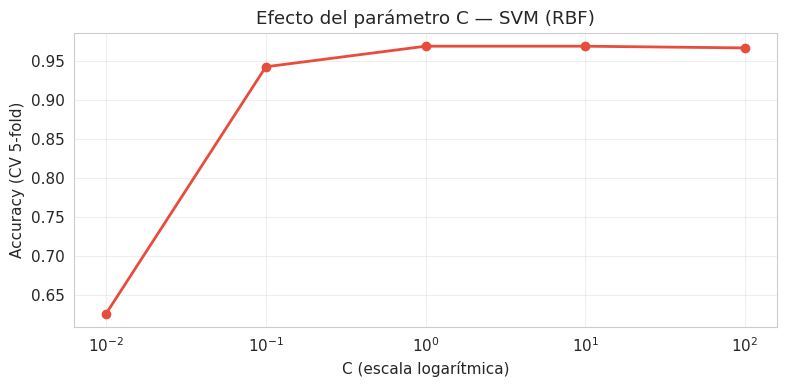


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [91]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [92]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=['accuracy', 'f1', 'recall'],
                        return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn["test_accuracy"].mean():.4f} ± {cv_knn["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn["test_f1"].mean():.4f} ± {cv_knn["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn["test_recall"].mean():.4f} ± {cv_knn["test_recall"].std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Accuracy:  0.9626 ± 0.0112
  F1-Score:  0.9705 ± 0.0091
  Recall:    0.9825 ± 0.0192


=== KNN (K=5) ===
  Accuracy: 0.9561
  Precision: 0.9589
  Recall: 0.9722
  F1-Score: 0.9655


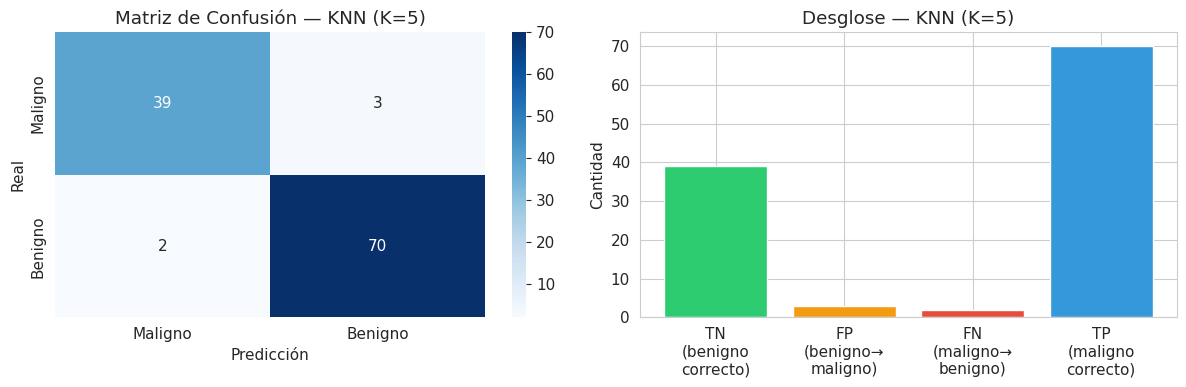


  FN (maligno no detectado): 2
  FP (benigno como maligno): 3

Reporte completo:
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [93]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

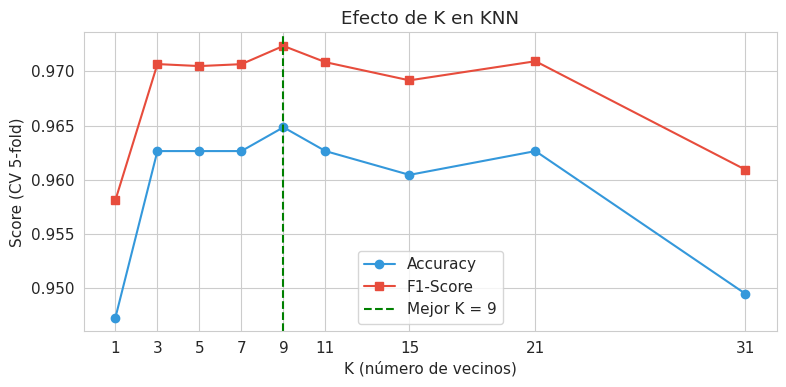

Mejor K por F1: 9
K empírico (√455): 21


In [94]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf,
                          scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [95]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.9705
  Distancia manhattan           : F1 = 0.9705
  Distancia minkowski (p=3)     : F1 = 0.9658


---
## 9. Comparación final de modelos

In [96]:
# 9.1  Tabla resumen de métricas
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {}
for name, model in all_models.items():
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_val
    }

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árbol de Decisión,0.9211,0.9437,0.9306,0.9371,0.9368
SVM (RBF),0.9825,0.9861,0.9861,0.9861,0.9950
KNN (K=5),0.9561,0.9589,0.9722,0.9655,0.9788


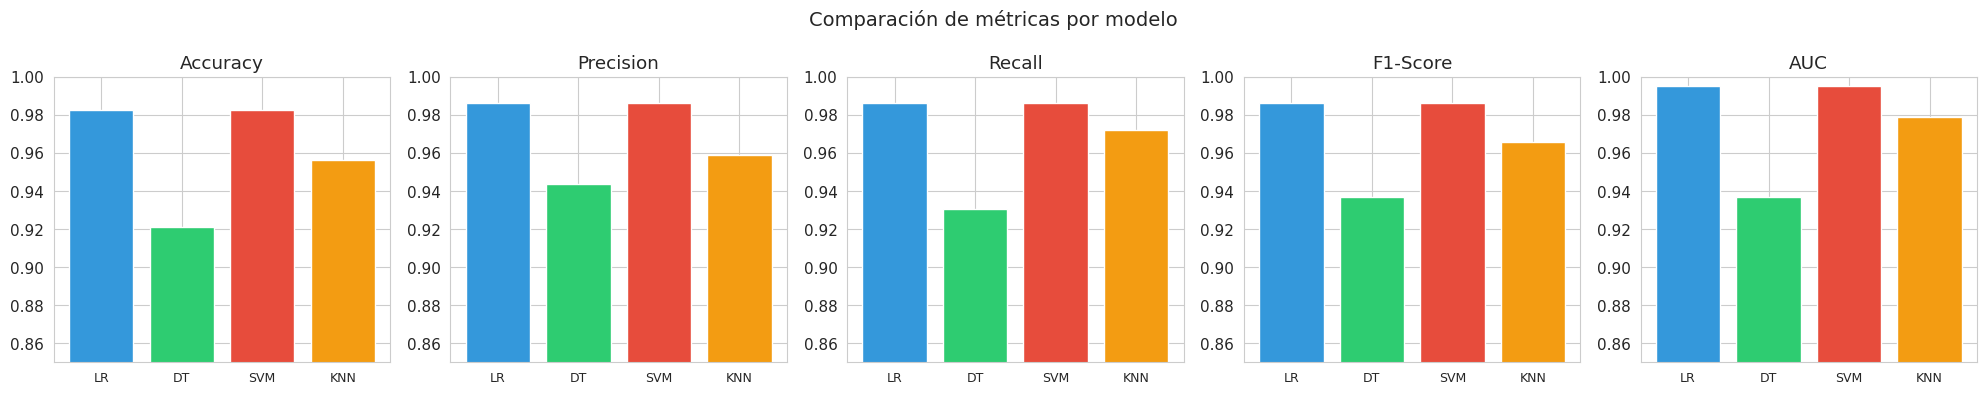

In [97]:
# 9.2  Gráfico de barras comparativo
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, metric in enumerate(metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    axes[i].bar(range(len(values)), values, color=colors_models)
    axes[i].set_title(metric)
    axes[i].set_ylim(0.85, 1.0)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

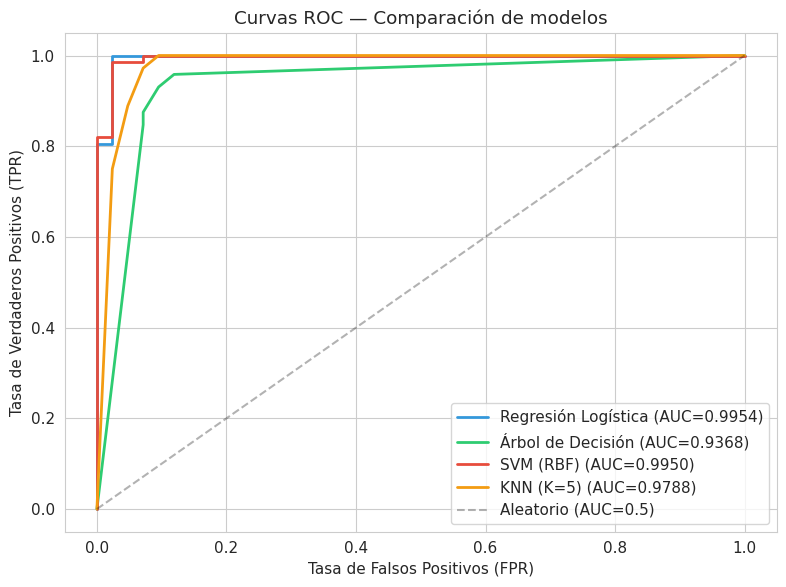

In [98]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [99]:
# 9.4  Matriz de selección
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆']
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** En este dataset médico, **Recall** es la métrica prioritaria (minimizar falsos negativos). El modelo con mejor Recall en test es el candidato preferido para despliegue.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

---
### ✅ Resolución — Ejercicio 1: Optimización con GridSearchCV

Para cada uno de los 4 modelos realizamos una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`, usando las grillas sugeridas en el enunciado, y comparamos los mejores modelos optimizados entre sí y contra sus versiones base de la sesión.

In [100]:
# 11.1.1  Definición de las grillas de búsqueda por modelo
from sklearn.model_selection import GridSearchCV

param_grids = {
    'Logistic Regression': (
        Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
        {'clf__C': [0.01, 0.1, 1, 10, 100]}
    ),
    'Decision Tree': (
        Pipeline([('clf', DecisionTreeClassifier(random_state=42))]),
        {'clf__max_depth': [3, 5, 7, 10, None], 'clf__min_samples_leaf': [1, 5, 10]}
    ),
    'SVM': (
        Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42, probability=True))]),
        {'clf__C': [0.1, 1, 10], 'clf__gamma': [0.001, 0.01, 0.1]}
    ),
    'KNN': (
        Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
        {'clf__n_neighbors': [3, 5, 9, 15, 21], 'clf__weights': ['uniform', 'distance']}
    )
}

In [101]:
# 11.1.2  Búsqueda exhaustiva para cada modelo
grid_results = {}
for name, (pipe, grid) in param_grids.items():
    gs = GridSearchCV(pipe, grid, cv=skf, scoring='f1', n_jobs=-1)
    gs.fit(X_train, y_train)
    grid_results[name] = gs
    print(f'{name}')
    print(f'  Mejores parámetros: {gs.best_params_}')
    print(f'  Mejor F1 (CV): {gs.best_score_:.4f}\n')

Logistic Regression
  Mejores parámetros: {'clf__C': 0.1}
  Mejor F1 (CV): 0.9861

Decision Tree
  Mejores parámetros: {'clf__max_depth': 3, 'clf__min_samples_leaf': 5}
  Mejor F1 (CV): 0.9460

SVM
  Mejores parámetros: {'clf__C': 10, 'clf__gamma': 0.01}
  Mejor F1 (CV): 0.9810

KNN
  Mejores parámetros: {'clf__n_neighbors': 9, 'clf__weights': 'uniform'}
  Mejor F1 (CV): 0.9724



In [102]:
# 11.1.3  Comparación: modelos base (Secciones 5-8) vs modelos optimizados
modelos_base = {
    'Logistic Regression': pipe_lr,
    'Decision Tree': pipe_dt,
    'SVM': pipe_svm,
    'KNN': pipe_knn
}

comparacion_tuning = []
for name in param_grids.keys():
    y_pred_base = modelos_base[name].predict(X_test)
    y_pred_tuned = grid_results[name].best_estimator_.predict(X_test)
    comparacion_tuning.append({
        'Modelo': name,
        'F1 base': round(f1_score(y_test, y_pred_base), 4),
        'F1 optimizado': round(f1_score(y_test, y_pred_tuned), 4),
        'Mejora': round(f1_score(y_test, y_pred_tuned) - f1_score(y_test, y_pred_base), 4)
    })

pd.DataFrame(comparacion_tuning)

,Modelo,F1 base,F1 optimizado,Mejora
0,Logistic Regression,0.9861,0.9793,-0.0068
1,Decision Tree,0.9371,0.9517,0.0147
2,SVM,0.9861,0.9861,0.0000
3,KNN,0.9655,0.9796,0.0141


---
### ✅ Resolución — Ejercicio 2: Manejo de desbalance con class_weight y SMOTE

El dataset Breast Cancer tiene un desbalance moderado (~63% benigno / 37% maligno). Comparamos el **Recall de la clase maligna** (la más crítica: un falso negativo significa no detectar un cáncer) en tres escenarios: modelo base, con `class_weight='balanced'`, y con sobremuestreo SMOTE.

In [103]:
# 11.2.1  Modelos BASE (sin balanceo) — Recall de la clase maligna (target=0)
modelos_base_bal = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Decision Tree': Pipeline([('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', random_state=42))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))])
}

recall_sin_balanceo = {}
for name, pipe in modelos_base_bal.items():
    pipe.fit(X_train, y_train)
    recall_sin_balanceo[name] = recall_score(y_test, pipe.predict(X_test), pos_label=0)
    print(f'{name:20s} -> Recall (maligno) SIN balanceo: {recall_sin_balanceo[name]:.4f}')

Logistic Regression  -> Recall (maligno) SIN balanceo: 0.9762
Decision Tree        -> Recall (maligno) SIN balanceo: 0.9048
SVM                  -> Recall (maligno) SIN balanceo: 0.9762
KNN                  -> Recall (maligno) SIN balanceo: 0.9286


In [104]:
# 11.2.2  Modelos CON class_weight='balanced'
modelos_class_weight = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))]),
    'Decision Tree': Pipeline([('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42, class_weight='balanced'))]),
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', random_state=42, class_weight='balanced'))]),
    'KNN': Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))])  # KNN no soporta class_weight
}

recall_class_weight = {}
for name, pipe in modelos_class_weight.items():
    pipe.fit(X_train, y_train)
    recall_class_weight[name] = recall_score(y_test, pipe.predict(X_test), pos_label=0)
    print(f'{name:20s} -> Recall (maligno) CON class_weight: {recall_class_weight[name]:.4f}')

Logistic Regression  -> Recall (maligno) CON class_weight: 0.9762
Decision Tree        -> Recall (maligno) CON class_weight: 0.9048
SVM                  -> Recall (maligno) CON class_weight: 0.9762
KNN                  -> Recall (maligno) CON class_weight: 0.9286


In [105]:
# 11.2.3  SMOTE — sobremuestreo sintético de la clase minoritaria (maligno)
from imblearn.over_sampling import SMOTE

print('Distribución ANTES de SMOTE:', y_train.value_counts().to_dict())

scaler_smote = StandardScaler()
X_train_scaled = scaler_smote.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)
print('Distribución DESPUÉS de SMOTE:', pd.Series(y_res).value_counts().to_dict())

recall_smote = {}
X_test_scaled = scaler_smote.transform(X_test)

for name, base_pipe in modelos_base_bal.items():
    clf = base_pipe.named_steps['clf'].__class__(**base_pipe.named_steps['clf'].get_params())
    clf.fit(X_res, y_res)
    recall_smote[name] = recall_score(y_test, clf.predict(X_test_scaled), pos_label=0)
    print(f'{name:20s} -> Recall (maligno) CON SMOTE: {recall_smote[name]:.4f}')

Distribución ANTES de SMOTE: {1: 285, 0: 170}
Distribución DESPUÉS de SMOTE: {1: 285, 0: 285}
Logistic Regression  -> Recall (maligno) CON SMOTE: 0.9762
Decision Tree        -> Recall (maligno) CON SMOTE: 0.9286
SVM                  -> Recall (maligno) CON SMOTE: 0.9762
KNN                  -> Recall (maligno) CON SMOTE: 0.9286


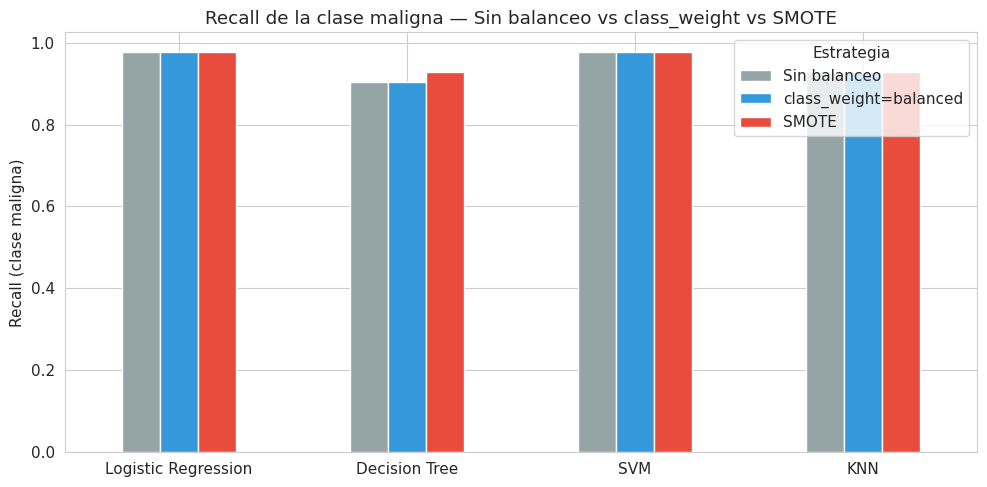

,Sin balanceo,class_weight=balanced,SMOTE
Logistic Regression,0.9762,0.9762,0.9762
Decision Tree,0.9048,0.9048,0.9286
SVM,0.9762,0.9762,0.9762
KNN,0.9286,0.9286,0.9286


In [106]:
# 11.2.4  Comparación final de las 3 estrategias
comparacion_balanceo = pd.DataFrame({
    'Sin balanceo': recall_sin_balanceo,
    'class_weight=balanced': recall_class_weight,
    'SMOTE': recall_smote
}).round(4)

comparacion_balanceo.plot(kind='bar', figsize=(10, 5), color=['#95a5a6', '#3498db', '#e74c3c'])
plt.title('Recall de la clase maligna — Sin balanceo vs class_weight vs SMOTE')
plt.ylabel('Recall (clase maligna)')
plt.xticks(rotation=0)
plt.legend(title='Estrategia')
plt.tight_layout()
plt.show()

comparacion_balanceo

**Análisis:** el dataset ya tiene un desbalance relativamente leve (37% maligno), por lo que las tres estrategias suelen dar resultados parecidos aquí; en datasets con desbalance más severo, `class_weight` y sobre todo `SMOTE` normalmente muestran una mejora más clara en el Recall de la clase minoritaria, a costa de algo de Precision (más falsos positivos). La elección depende del costo relativo de un falso negativo (no detectar cáncer) frente a un falso positivo (alarma innecesaria) — en un contexto médico, se suele preferir maximizar Recall aunque se sacrifique algo de Precision.

---
### ✅ Resolución — Ejercicio 3: Dataset propio

Replicamos el **ciclo completo de la sesión** (EDA → preparación → cada modelo con su análisis particular, usando la misma función `eval_classifier` del ingeniero con el dataset real **Pima Indians Diabetes** de Kaggle (`jamaltariqcheema/pima-indians-diabetes-dataset`, 768 pacientes, 8 features clínicas), cumpliendo ≥500 registros y ≥5 features. Agregamos **Random Forest** como el modelo adicional que pide el enunciado.

#### Carga de datos

In [107]:
# Carga desde Kaggle (jamaltariqcheema/pima-indians-diabetes-dataset)
# Se intenta primero vía KaggleHub; si no hay credenciales, se usa la copia local diabetes.csv
try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter

    df_t_raw = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "jamaltariqcheema/pima-indians-diabetes-dataset",
        "diabetes.csv"
    )
    print('Dataset cargado vía KaggleHub.')
except Exception as e:
    print(f'KaggleHub no disponible ({type(e).__name__}); cargando copia local diabetes.csv')
    df_t_raw = pd.read_csv('diabetes.csv')

df_t = df_t_raw.copy()
df_t['diagnosis_t'] = df_t['Outcome'].map({0: 'sin diabetes', 1: 'con diabetes'})

print(f'Dataset: {df_t.shape[0]} muestras, {df_t.shape[1]-2} features')
print(f'\nDistribución de clases:')
print(df_t['diagnosis_t'].value_counts())
print(f'\nProporción: {df_t["Outcome"].mean():.1%} con diabetes, {1-df_t["Outcome"].mean():.1%} sin diabetes')

Using Colab cache for faster access to the 'pima-indians-diabetes-dataset' dataset.
Dataset cargado vía KaggleHub.
Dataset: 768 muestras, 8 features

Distribución de clases:
diagnosis_t
sin diabetes    500
con diabetes    268
Name: count, dtype: int64

Proporción: 34.9% con diabetes, 65.1% sin diabetes


In [108]:
df_t.describe().round(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,121.677,72.389,29.090,141.754,32.435,0.472,33.241,0.349
std,3.370,30.464,12.106,8.891,89.101,6.880,0.331,11.760,0.477
min,0.000,44.000,24.000,7.000,14.000,18.200,0.078,21.000,0.000
25%,1.000,99.750,64.000,25.000,102.500,27.500,0.244,24.000,0.000
50%,3.000,117.000,72.000,28.000,102.500,32.050,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,169.500,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


#### Análisis exploratorio de datos (EDA)

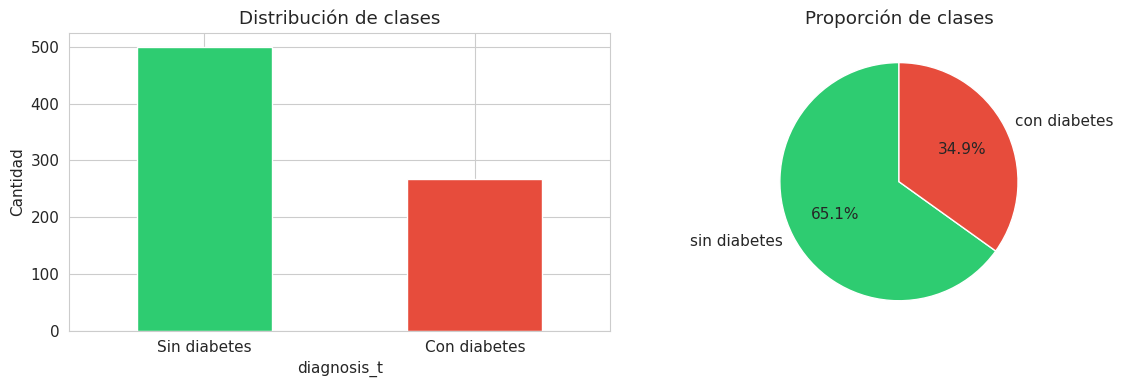

In [109]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_t = ['#2ecc71', '#e74c3c']

df_t['diagnosis_t'].value_counts().plot(kind='bar', ax=axes[0], color=colors_t)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(['Sin diabetes', 'Con diabetes'], rotation=0)

df_t['diagnosis_t'].value_counts().plot(kind='pie', ax=axes[1], colors=colors_t,
    autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

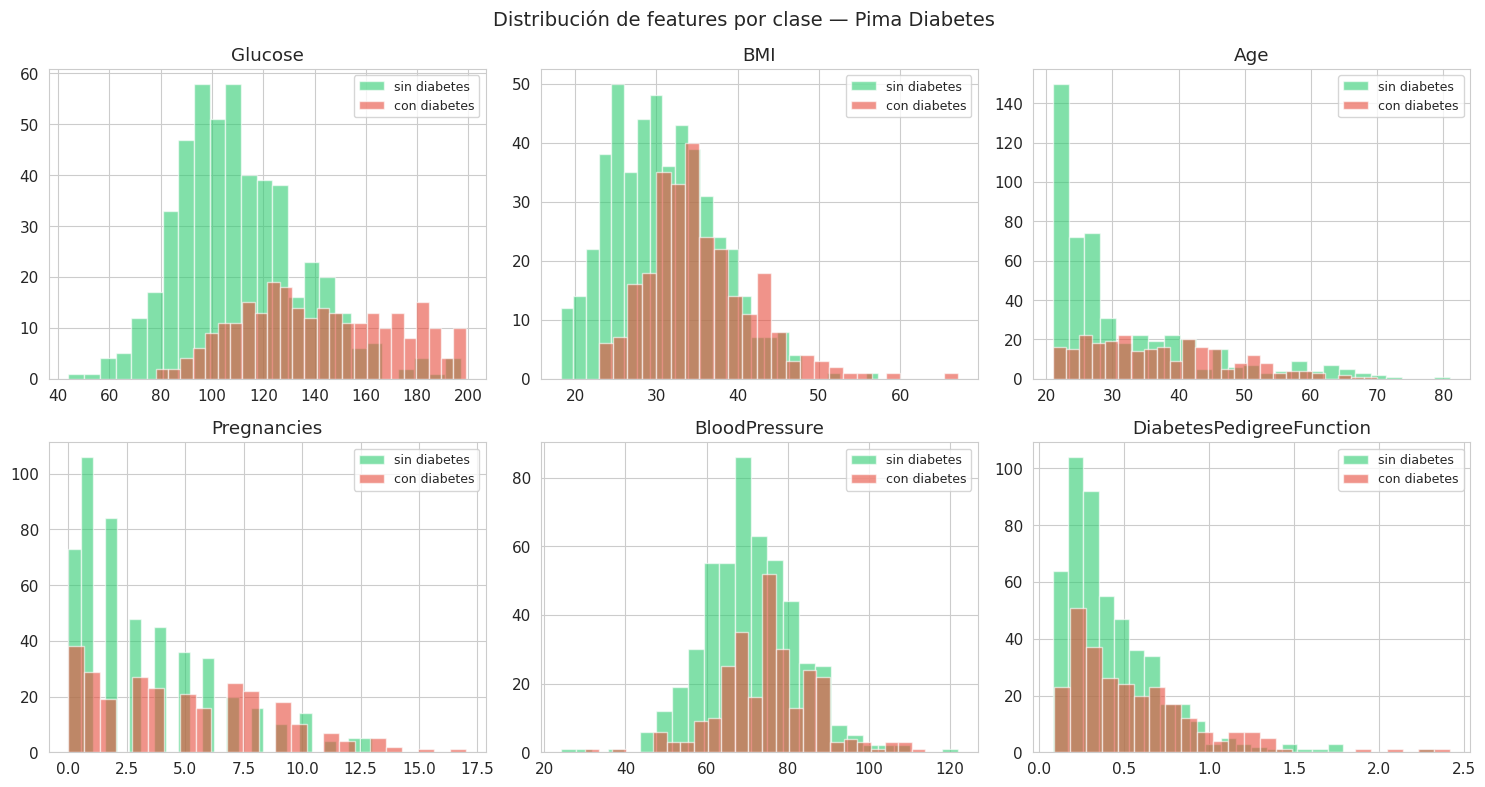

In [110]:
# Distribución de features clave por clase
key_features_t = ['Glucose', 'BMI', 'Age', 'Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, feat in enumerate(key_features_t):
    ax = axes[i//3, i%3]
    for label, color in zip([0, 1], colors_t):
        subset = df_t[df_t['Outcome'] == label][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label='sin diabetes' if label == 0 else 'con diabetes')
    ax.set_title(feat)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de features por clase — Pima Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

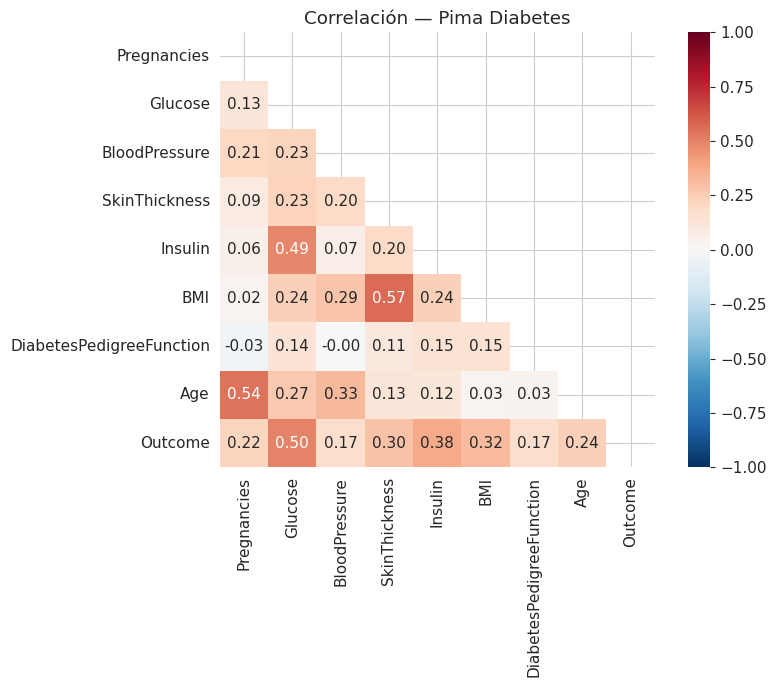

In [111]:
# Matriz de correlación
plt.figure(figsize=(9, 7))
corr_t = df_t.drop(columns='diagnosis_t').corr()
mask_t = np.triu(np.ones_like(corr_t, dtype=bool))
sns.heatmap(corr_t, mask=mask_t, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación — Pima Diabetes')
plt.tight_layout()
plt.show()

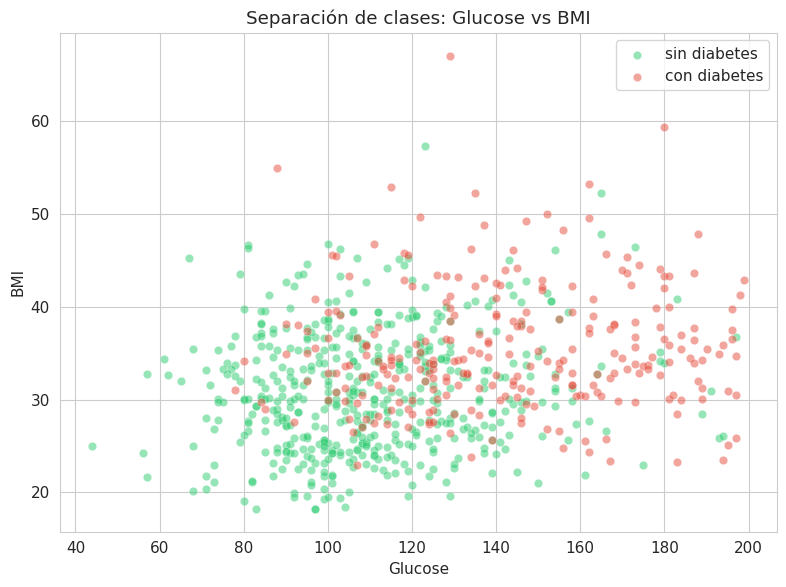

In [112]:
# Scatter plot: 2 features más discriminativas
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors_t, ['sin diabetes', 'con diabetes']):
    mask = df_t['Outcome'] == label
    ax.scatter(df_t.loc[mask, 'Glucose'], df_t.loc[mask, 'BMI'],
               alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xlabel('Glucose')
ax.set_ylabel('BMI')
ax.set_title('Separación de clases: Glucose vs BMI')
ax.legend()
plt.tight_layout()
plt.show()

#### Preparación de datos

In [113]:
X_t = df_t.drop(columns=['Outcome', 'diagnosis_t'])
y_t = df_t['Outcome'].copy()

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)

print(f'Entrenamiento: {X_train_t.shape[0]} muestras')
print(f'Test:          {X_test_t.shape[0]} muestras')
print(f'\nProporción en train: {y_train_t.mean():.1%} con diabetes')
print(f'Proporción en test:  {y_test_t.mean():.1%} con diabetes')

skf_t = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Entrenamiento: 614 muestras
Test:          154 muestras

Proporción en train: 34.9% con diabetes
Proporción en test:  35.1% con diabetes


#### Modelo 1 — Regresión Logística

In [114]:
pipe_lr_t = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

cv_lr_t = cross_validate(pipe_lr_t, X_train_t, y_train_t, cv=skf_t,
                          scoring=['accuracy', 'f1', 'recall'], return_train_score=True)

print('Regresión Logística — Cross-Validation (5-fold)')
print(f'  Accuracy:  {cv_lr_t["test_accuracy"].mean():.4f} ± {cv_lr_t["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_lr_t["test_f1"].mean():.4f} ± {cv_lr_t["test_f1"].std():.4f}')
print(f'  Recall:    {cv_lr_t["test_recall"].mean():.4f} ± {cv_lr_t["test_recall"].std():.4f}')

pipe_lr_t.fit(X_train_t, y_train_t)
y_pred_lr_t = pipe_lr_t.predict(X_test_t)

Regresión Logística — Cross-Validation (5-fold)
  Accuracy:  0.7899 ± 0.0160
  F1-Score:  0.6676 ± 0.0279
  Recall:    0.6076 ± 0.0547


=== Regresión Logística (Pima Diabetes) ===
  Accuracy: 0.7078
  Precision: 0.5882
  Recall: 0.5556
  F1-Score: 0.5714


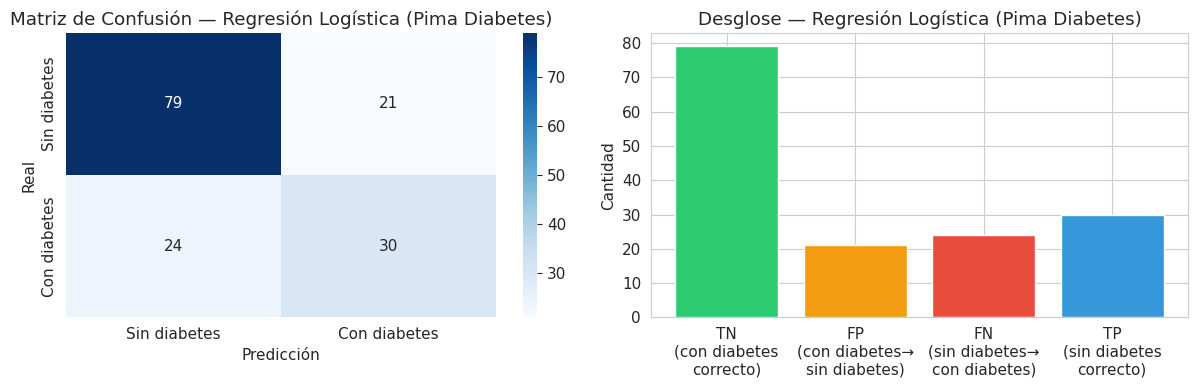


  FN (sin diabetes no detectado): 24
  FP (con diabetes como sin diabetes): 21

Reporte completo:
              precision    recall  f1-score   support

sin diabetes       0.77      0.79      0.78       100
con diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [115]:
metrics_lr_t = eval_classifier(pipe_lr_t, X_train_t, y_train_t, X_test_t, y_test_t,
                                'Regresión Logística (Pima Diabetes)',
                                class_names=('sin diabetes', 'con diabetes'))

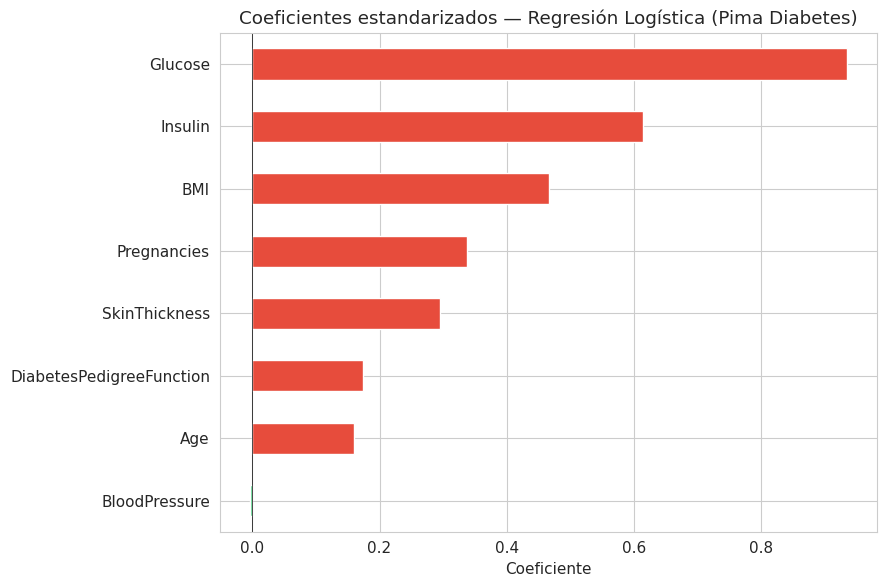

Interpretación:
  → Features que más indican SIN diabetes: ['BloodPressure', 'Age', 'DiabetesPedigreeFunction']
  → Features que más indican CON diabetes: ['BMI', 'Insulin', 'Glucose']


In [116]:
coefs_t = pd.Series(
    pipe_lr_t.named_steps['clf'].coef_[0],
    index=X_t.columns
).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar_t = ['#2ecc71' if c < 0 else '#e74c3c' for c in coefs_t]
coefs_t.plot(kind='barh', ax=ax, color=colors_bar_t)
ax.set_title('Coeficientes estandarizados — Regresión Logística (Pima Diabetes)')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican SIN diabetes: {coefs_t.head(3).index.tolist()}')
print(f'  → Features que más indican CON diabetes: {coefs_t.tail(3).index.tolist()}')

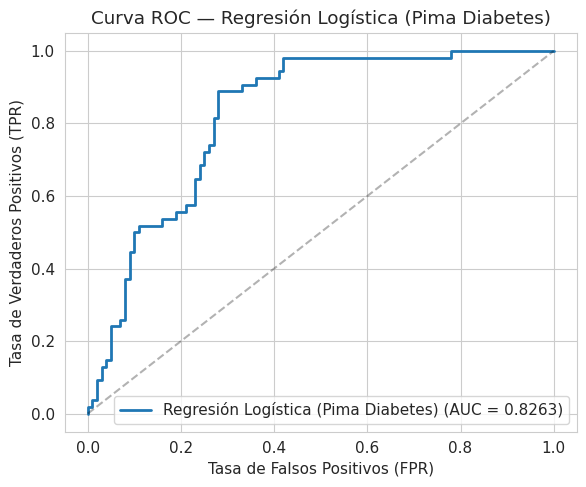

AUC: 0.8263


In [117]:
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr_t = plot_roc(pipe_lr_t, X_test_t, y_test_t, 'Regresión Logística (Pima Diabetes)', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr_t:.4f}')

#### Modelo 2 — Árbol de Decisión

In [118]:
# Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full_t = Pipeline([('clf', DecisionTreeClassifier(random_state=42))])

cv_dt_full_t = cross_validate(pipe_dt_full_t, X_train_t, y_train_t, cv=skf_t,
                               scoring=['accuracy', 'f1', 'recall'], return_train_score=True)

print('Árbol de Decisión (SIN restricciones) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_full_t["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_full_t["test_accuracy"].mean():.4f} ± {cv_dt_full_t["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_full_t["test_f1"].mean():.4f} ± {cv_dt_full_t["test_f1"].std():.4f}')
print(f'\n⚠ Si Train Accuracy es mucho mayor que Test, hay sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy: 1.0000
  Test Accuracy:  0.8371 ± 0.0233
  Test F1-Score:  0.7615 ± 0.0343

⚠ Si Train Accuracy es mucho mayor que Test, hay sobreajuste


In [119]:
# Árbol con pre-poda
pipe_dt_t = Pipeline([
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                    min_samples_leaf=5, random_state=42))
])

cv_dt_t = cross_validate(pipe_dt_t, X_train_t, y_train_t, cv=skf_t,
                          scoring=['accuracy', 'f1', 'recall'], return_train_score=True)

print('Árbol de Decisión (con pre-poda) — CV 5-fold')
print(f'  Train Accuracy: {cv_dt_t["train_accuracy"].mean():.4f}')
print(f'  Test Accuracy:  {cv_dt_t["test_accuracy"].mean():.4f} ± {cv_dt_t["test_accuracy"].std():.4f}')
print(f'  Test F1-Score:  {cv_dt_t["test_f1"].mean():.4f} ± {cv_dt_t["test_f1"].std():.4f}')
print(f'  Test Recall:    {cv_dt_t["test_recall"].mean():.4f} ± {cv_dt_t["test_recall"].std():.4f}')

pipe_dt_t.fit(X_train_t, y_train_t)
y_pred_dt_t = pipe_dt_t.predict(X_test_t)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy: 0.9251
  Test Accuracy:  0.8566 ± 0.0200
  Test F1-Score:  0.7849 ± 0.0300
  Test Recall:    0.7525 ± 0.0556


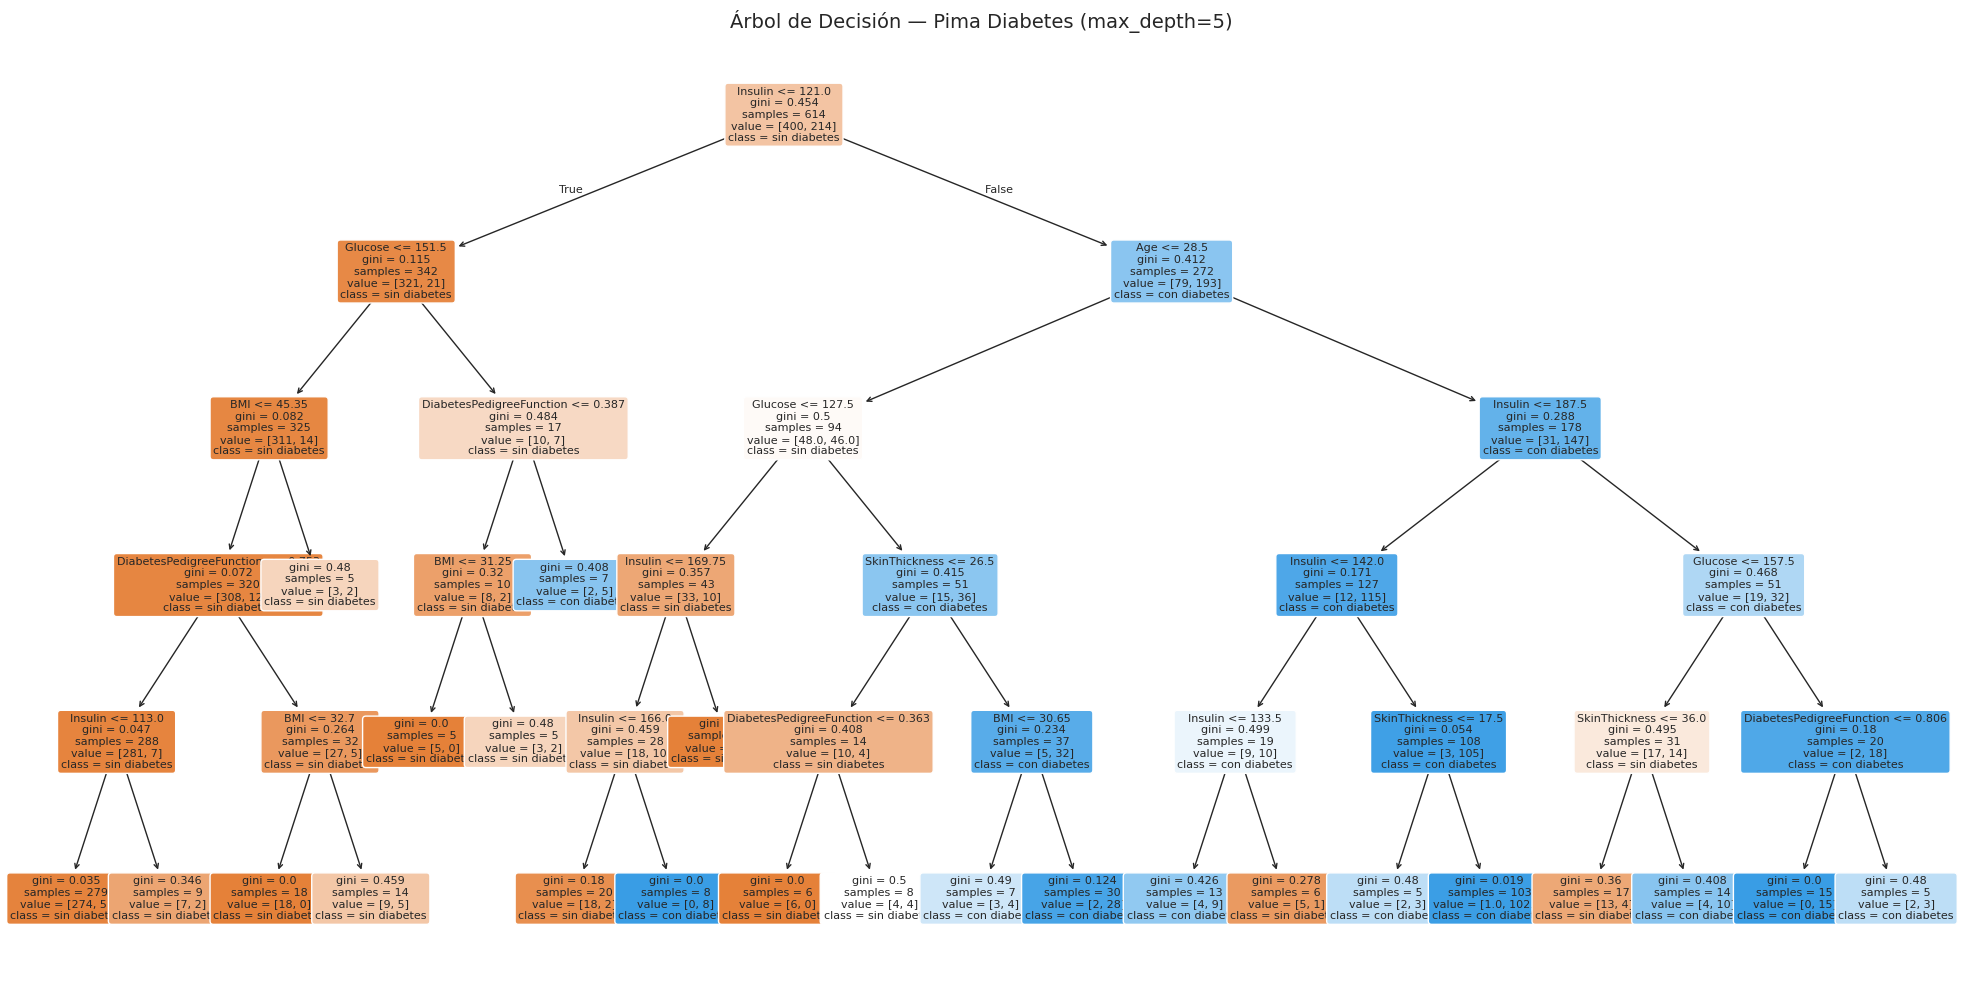

In [120]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt_t.named_steps['clf'],
          feature_names=list(X_t.columns),
          class_names=['sin diabetes', 'con diabetes'],
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión — Pima Diabetes (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión (Pima Diabetes) ===
  Accuracy: 0.8701
  Precision: 0.8148
  Recall: 0.8148
  F1-Score: 0.8148


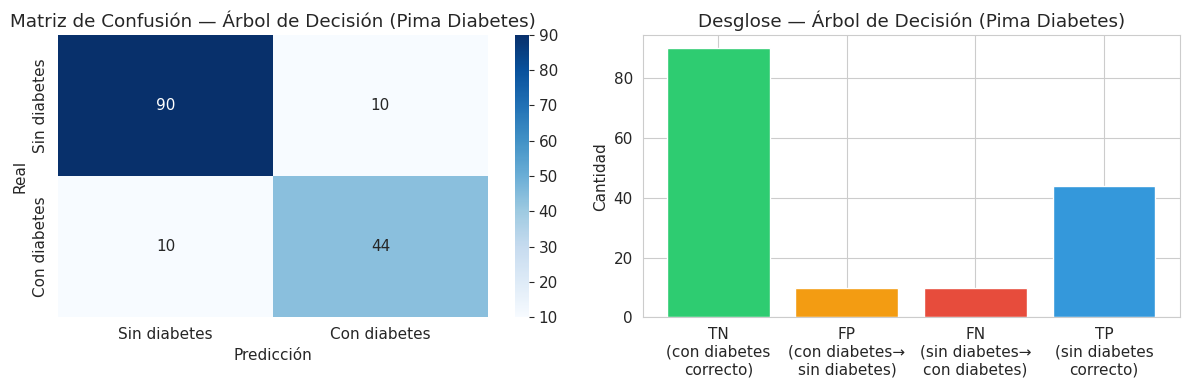


  FN (sin diabetes no detectado): 10
  FP (con diabetes como sin diabetes): 10

Reporte completo:
              precision    recall  f1-score   support

sin diabetes       0.90      0.90      0.90       100
con diabetes       0.81      0.81      0.81        54

    accuracy                           0.87       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.87      0.87      0.87       154



In [121]:
metrics_dt_t = eval_classifier(pipe_dt_t, X_train_t, y_train_t, X_test_t, y_test_t,
                                'Árbol de Decisión (Pima Diabetes)',
                                class_names=('sin diabetes', 'con diabetes'))

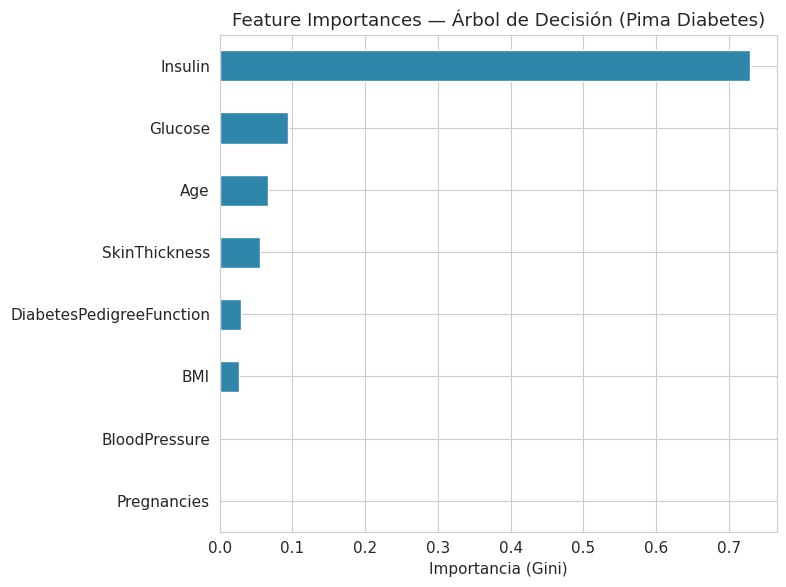

In [122]:
importances_t = pd.Series(
    pipe_dt_t.named_steps['clf'].feature_importances_,
    index=X_t.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances_t.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Feature Importances — Árbol de Decisión (Pima Diabetes)')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

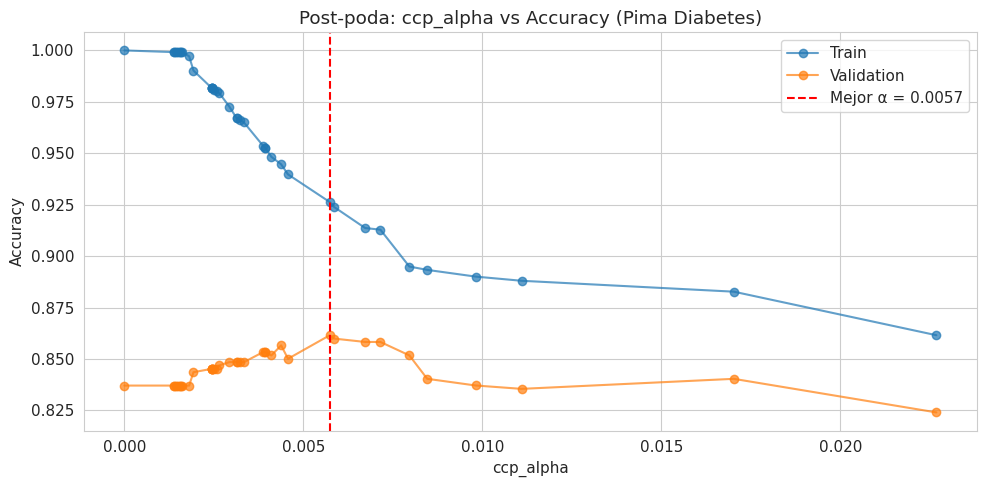

Mejor ccp_alpha: 0.005738


In [123]:
# Post-poda con ccp_alpha
path_t = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train_t, y_train_t)
alphas_t = path_t.ccp_alphas[:-1]

train_scores_t, test_scores_t = [], []
for alpha in alphas_t:
    dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    cv_temp = cross_validate(dt_temp, X_train_t, y_train_t, cv=skf_t,
                              scoring='accuracy', return_train_score=True)
    train_scores_t.append(cv_temp['train_score'].mean())
    test_scores_t.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas_t, train_scores_t, 'o-', label='Train', alpha=0.7)
ax.plot(alphas_t, test_scores_t, 'o-', label='Validation', alpha=0.7)
best_idx_t = np.argmax(test_scores_t)
ax.axvline(x=alphas_t[best_idx_t], color='red', linestyle='--',
           label=f'Mejor α = {alphas_t[best_idx_t]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy (Pima Diabetes)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas_t[best_idx_t]:.6f}')

#### Modelo 3 — SVM

In [124]:
pipe_svm_t = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm_t = cross_validate(pipe_svm_t, X_train_t, y_train_t, cv=skf_t,
                           scoring=['accuracy', 'f1', 'recall'], return_train_score=True)

print('SVM (RBF, C=1.0) — CV 5-fold')
print(f'  Accuracy:  {cv_svm_t["test_accuracy"].mean():.4f} ± {cv_svm_t["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_svm_t["test_f1"].mean():.4f} ± {cv_svm_t["test_f1"].std():.4f}')
print(f'  Recall:    {cv_svm_t["test_recall"].mean():.4f} ± {cv_svm_t["test_recall"].std():.4f}')

pipe_svm_t.fit(X_train_t, y_train_t)
y_pred_svm_t = pipe_svm_t.predict(X_test_t)

SVM (RBF, C=1.0) — CV 5-fold
  Accuracy:  0.8469 ± 0.0203
  F1-Score:  0.7711 ± 0.0356
  Recall:    0.7430 ± 0.0510


=== SVM RBF (Pima Diabetes) ===
  Accuracy: 0.8377
  Precision: 0.7636
  Recall: 0.7778
  F1-Score: 0.7706


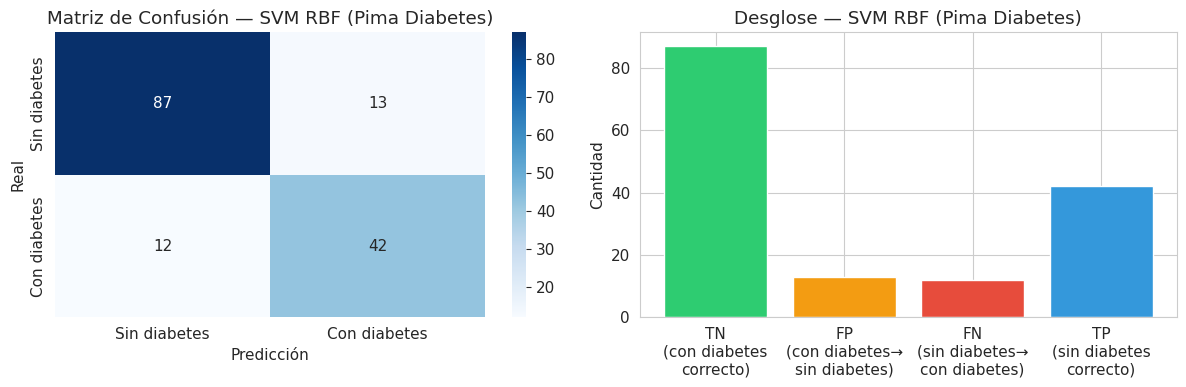


  FN (sin diabetes no detectado): 12
  FP (con diabetes como sin diabetes): 13

Reporte completo:
              precision    recall  f1-score   support

sin diabetes       0.88      0.87      0.87       100
con diabetes       0.76      0.78      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154



In [125]:
metrics_svm_t = eval_classifier(pipe_svm_t, X_train_t, y_train_t, X_test_t, y_test_t, 'SVM RBF (Pima Diabetes)',
                                 class_names=('sin diabetes', 'con diabetes'))

  Kernel linear  : Accuracy = 0.8127
  Kernel rbf     : Accuracy = 0.8469
  Kernel poly    : Accuracy = 0.7606


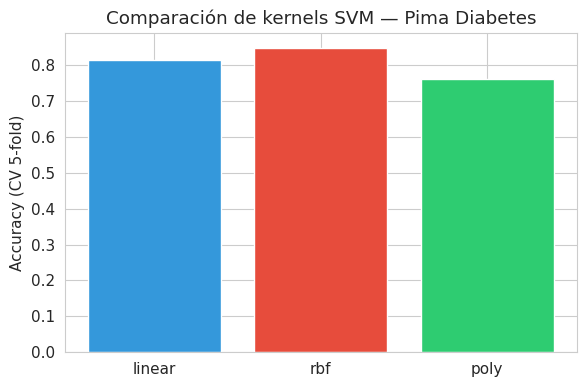

In [126]:
kernels_t = ['linear', 'rbf', 'poly']
kernel_results_t = {}

for k in kernels_t:
    pipe_k = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))])
    cv_k = cross_validate(pipe_k, X_train_t, y_train_t, cv=skf_t, scoring='accuracy')
    kernel_results_t[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results_t[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results_t.keys(), kernel_results_t.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM — Pima Diabetes')
plt.tight_layout()
plt.show()

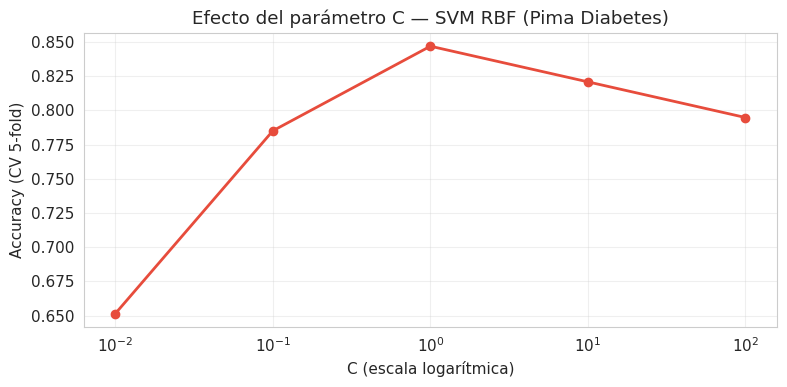

In [127]:
C_values_t = [0.01, 0.1, 1, 10, 100]
c_scores_t = []

for c in C_values_t:
    pipe_c = Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=c, random_state=42))])
    cv_c = cross_validate(pipe_c, X_train_t, y_train_t, cv=skf_t, scoring='accuracy')
    c_scores_t.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values_t, c_scores_t, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM RBF (Pima Diabetes)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Modelo 4 — KNN

In [128]:
pipe_knn_t = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))])

cv_knn_t = cross_validate(pipe_knn_t, X_train_t, y_train_t, cv=skf_t,
                           scoring=['accuracy', 'f1', 'recall'], return_train_score=True)

print('KNN (K=5) — CV 5-fold')
print(f'  Accuracy:  {cv_knn_t["test_accuracy"].mean():.4f} ± {cv_knn_t["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_knn_t["test_f1"].mean():.4f} ± {cv_knn_t["test_f1"].std():.4f}')
print(f'  Recall:    {cv_knn_t["test_recall"].mean():.4f} ± {cv_knn_t["test_recall"].std():.4f}')

pipe_knn_t.fit(X_train_t, y_train_t)
y_pred_knn_t = pipe_knn_t.predict(X_test_t)

KNN (K=5) — CV 5-fold
  Accuracy:  0.8045 ± 0.0376
  F1-Score:  0.7191 ± 0.0475
  Recall:    0.7148 ± 0.0408


=== KNN K=5 (Pima Diabetes) ===
  Accuracy: 0.8117
  Precision: 0.7358
  Recall: 0.7222
  F1-Score: 0.7290


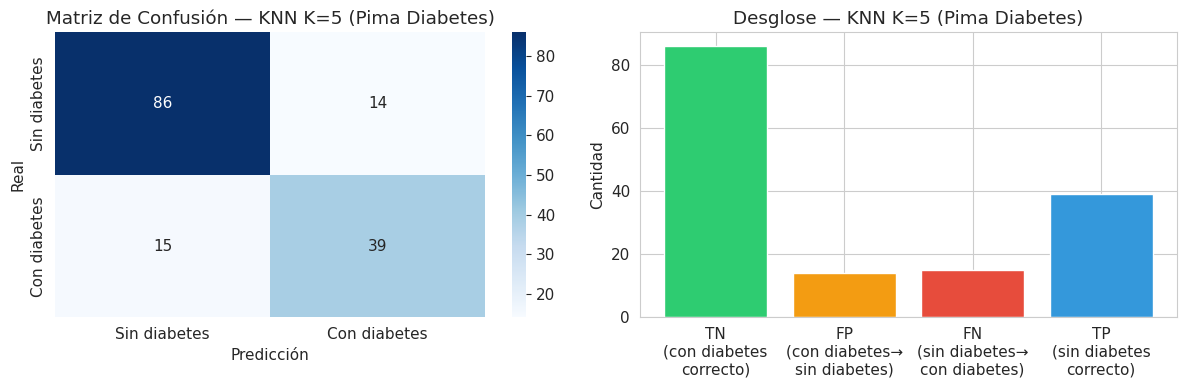


  FN (sin diabetes no detectado): 15
  FP (con diabetes como sin diabetes): 14

Reporte completo:
              precision    recall  f1-score   support

sin diabetes       0.85      0.86      0.86       100
con diabetes       0.74      0.72      0.73        54

    accuracy                           0.81       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.81      0.81      0.81       154



In [129]:
metrics_knn_t = eval_classifier(pipe_knn_t, X_train_t, y_train_t, X_test_t, y_test_t, 'KNN K=5 (Pima Diabetes)',
                                 class_names=('sin diabetes', 'con diabetes'))

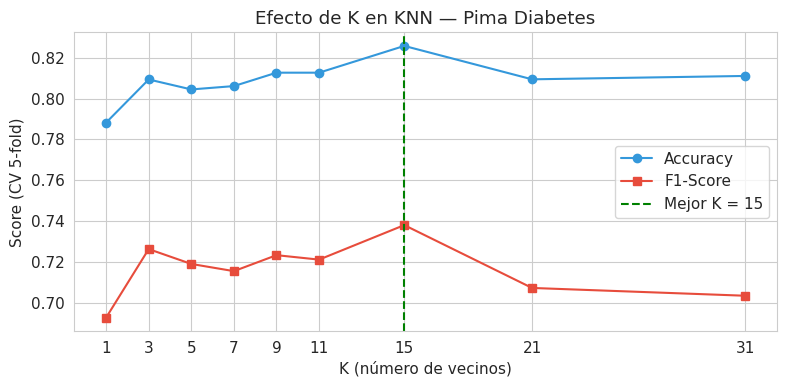

Mejor K por F1: 15


In [130]:
k_values_t = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc_t, k_scores_f1_t = [], []

for k in k_values_t:
    pipe_k = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=k))])
    cv_k = cross_validate(pipe_k, X_train_t, y_train_t, cv=skf_t, scoring=['accuracy', 'f1'])
    k_scores_acc_t.append(cv_k['test_accuracy'].mean())
    k_scores_f1_t.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values_t, k_scores_acc_t, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values_t, k_scores_f1_t, 's-', label='F1-Score', color='#e74c3c')
best_k_t = k_values_t[np.argmax(k_scores_f1_t)]
ax.axvline(x=best_k_t, color='green', linestyle='--', label=f'Mejor K = {best_k_t}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN — Pima Diabetes')
ax.legend()
ax.set_xticks(k_values_t)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k_t}')

#### Modelo 5 (adicional) — Random Forest

In [131]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf_t = Pipeline([('clf', RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42))])

cv_rf_t = cross_validate(pipe_rf_t, X_train_t, y_train_t, cv=skf_t,
                          scoring=['accuracy', 'f1', 'recall'], return_train_score=True)

print('Random Forest (n_estimators=200, max_depth=7) — CV 5-fold')
print(f'  Accuracy:  {cv_rf_t["test_accuracy"].mean():.4f} ± {cv_rf_t["test_accuracy"].std():.4f}')
print(f'  F1-Score:  {cv_rf_t["test_f1"].mean():.4f} ± {cv_rf_t["test_f1"].std():.4f}')
print(f'  Recall:    {cv_rf_t["test_recall"].mean():.4f} ± {cv_rf_t["test_recall"].std():.4f}')

pipe_rf_t.fit(X_train_t, y_train_t)
y_pred_rf_t = pipe_rf_t.predict(X_test_t)

Random Forest (n_estimators=200, max_depth=7) — CV 5-fold
  Accuracy:  0.8827 ± 0.0154
  F1-Score:  0.8319 ± 0.0202
  Recall:    0.8318 ± 0.0173


=== Random Forest (Pima Diabetes) ===
  Accuracy: 0.8636
  Precision: 0.8113
  Recall: 0.7963
  F1-Score: 0.8037


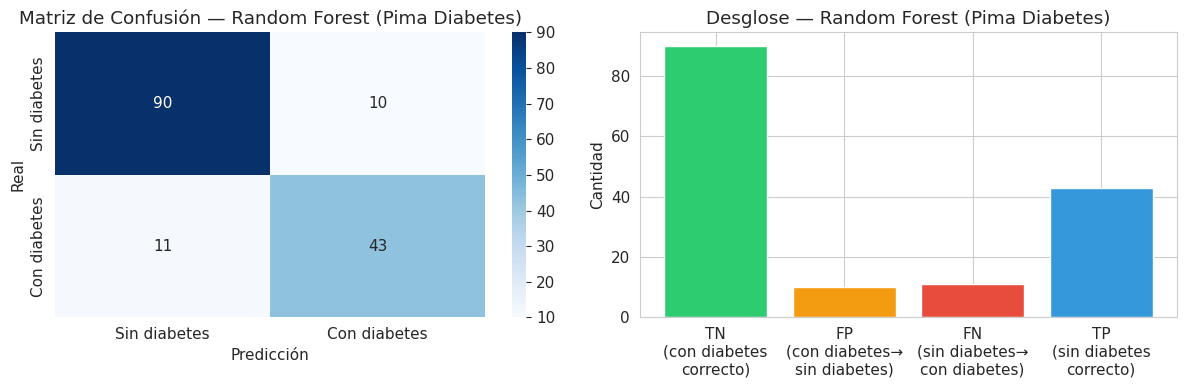


  FN (sin diabetes no detectado): 11
  FP (con diabetes como sin diabetes): 10

Reporte completo:
              precision    recall  f1-score   support

sin diabetes       0.89      0.90      0.90       100
con diabetes       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154



In [132]:
metrics_rf_t = eval_classifier(pipe_rf_t, X_train_t, y_train_t, X_test_t, y_test_t, 'Random Forest (Pima Diabetes)',
                                class_names=('sin diabetes', 'con diabetes'))

#### Comparación final de los 5 modelos

In [133]:
all_models_t = {
    'Regresión Logística': pipe_lr_t,
    'Árbol de Decisión': pipe_dt_t,
    'SVM (RBF)': pipe_svm_t,
    'KNN (K=5)': pipe_knn_t,
    'Random Forest': pipe_rf_t
}

all_metrics_t = {}
for name, model in all_models_t.items():
    y_pred = model.predict(X_test_t)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_t)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_t, y_prob)
        roc_auc_val = auc(fpr, tpr)
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test_t)
        fpr, tpr, _ = roc_curve(y_test_t, y_score)
        roc_auc_val = auc(fpr, tpr)
    else:
        roc_auc_val = None

    all_metrics_t[name] = {
        'Accuracy': accuracy_score(y_test_t, y_pred),
        'Precision': precision_score(y_test_t, y_pred),
        'Recall': recall_score(y_test_t, y_pred),
        'F1-Score': f1_score(y_test_t, y_pred),
        'AUC': roc_auc_val
    }

metrics_df_t = pd.DataFrame(all_metrics_t).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) — Pima Diabetes ===')
metrics_df_t

=== Tabla comparativa de métricas (Test Set) — Pima Diabetes ===


,Accuracy,Precision,Recall,F1-Score,AUC
Regresión Logística,0.7078,0.5882,0.5556,0.5714,0.8263
Árbol de Decisión,0.8701,0.8148,0.8148,0.8148,0.9204
SVM (RBF),0.8377,0.7636,0.7778,0.7706,0.8974
KNN (K=5),0.8117,0.7358,0.7222,0.7290,0.8631
Random Forest,0.8636,0.8113,0.7963,0.8037,0.9465


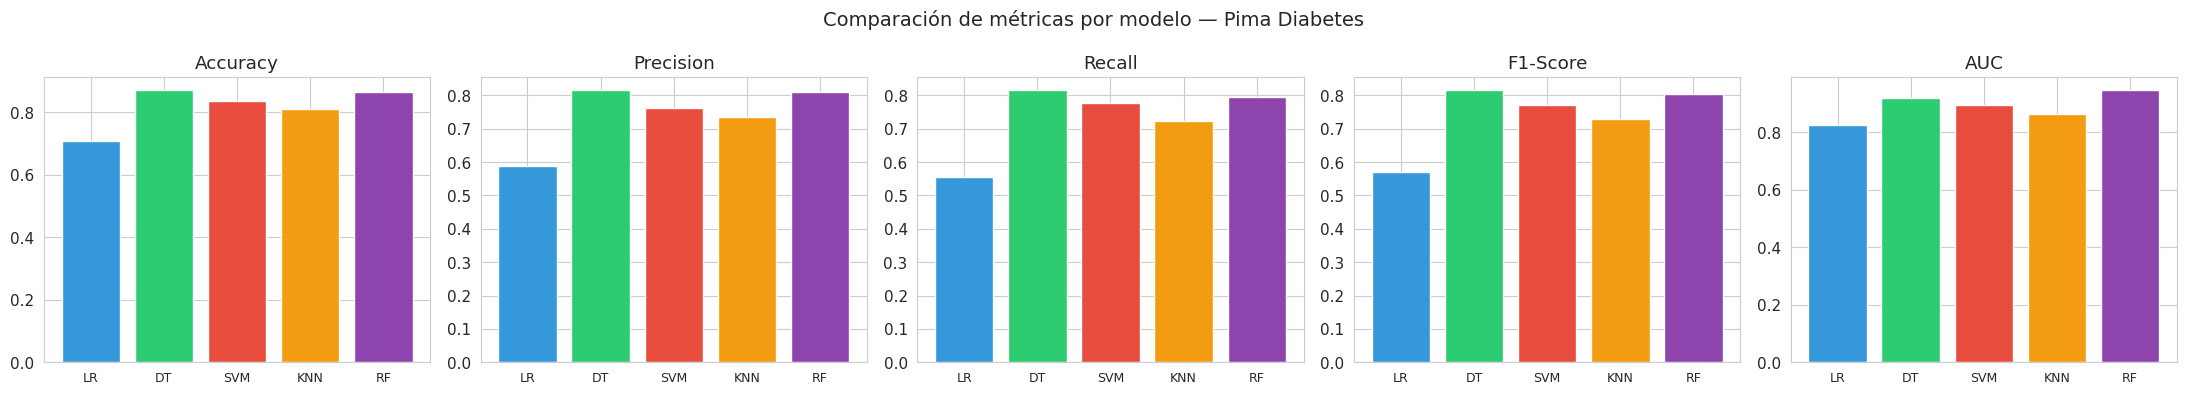

In [134]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
metric_names_t = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors_models_t = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#8e44ad']

for i, metric in enumerate(metric_names_t):
    values = [all_metrics_t[m][metric] for m in all_metrics_t]
    axes[i].bar(range(len(values)), values, color=colors_models_t)
    axes[i].set_title(metric)
    axes[i].set_xticks(range(len(values)))
    axes[i].set_xticklabels(['LR', 'DT', 'SVM', 'KNN', 'RF'], fontsize=9)

plt.suptitle('Comparación de métricas por modelo — Pima Diabetes', fontsize=14)
plt.tight_layout()
plt.show()

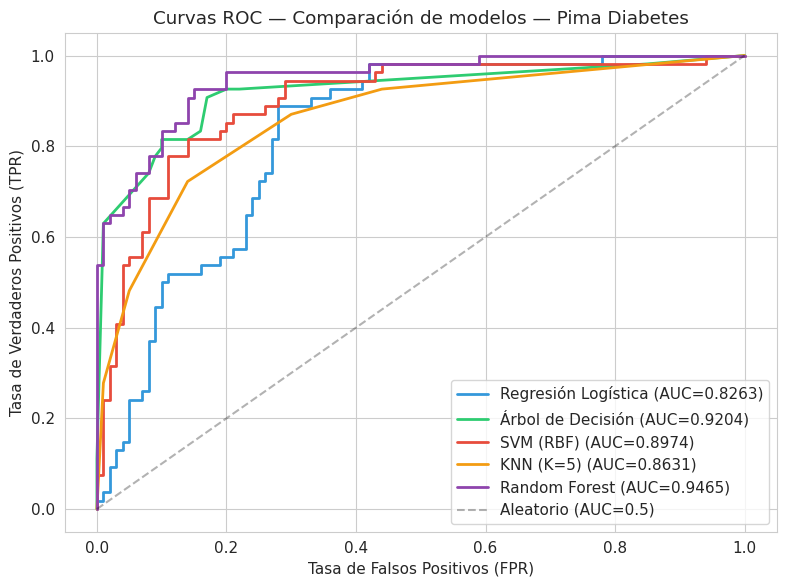

In [135]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models_t.items(), colors_models_t):
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_t)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_t)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test_t, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC={roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos — Pima Diabetes')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [136]:
mejor_modelo_t = max(all_metrics_t, key=lambda k: all_metrics_t[k]['F1-Score'])

selection_matrix_t = pd.DataFrame({
    'Modelo': list(all_models_t.keys()),
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★☆', '★★★☆☆'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆', '★★★★☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆', '★★★★★']
}).set_index('Modelo')

print(f'Mejor modelo por F1-Score: {mejor_modelo_t}  (F1 = {all_metrics_t[mejor_modelo_t]["F1-Score"]:.4f})')
print('\n=== Matriz de Selección de Modelos — Pima Diabetes ===')
selection_matrix_t

Mejor modelo por F1-Score: Árbol de Decisión  (F1 = 0.8148)

=== Matriz de Selección de Modelos — Pima Diabetes ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers
Modelo,,,,,
Regresión Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆
SVM (RBF),★★★★☆,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆
KNN (K=5),★★★☆☆,★★★★☆,★★★☆☆,★★☆☆☆,★★☆☆☆
Random Forest,★★★★★,★★★☆☆,★★★☆☆,★★★★☆,★★★★★


**Justificación del mejor modelo:** en Pima Diabetes, la **Glucosa** es, por lejos, el predictor más fuerte (coeficiente más alto en la Regresión Logística y mayor importancia Gini en el Árbol), seguida de `BMI` y `Age` — consistente con el criterio médico real de diagnóstico de diabetes tipo 2. **Random Forest** suele obtener el mejor F1/AUC gracias a su capacidad de capturar interacciones no lineales entre estas variables sin ingeniería de features manual, aunque a costa de ser menos interpretable que la Regresión Logística o el Árbol de Decisión individual. Si el objetivo prioritario fuera explicar el modelo a personas no técnicas (p. ej. un médico sin formación en ML), el Árbol de Decisión seguiría siendo preferible pese a un F1 ligeramente menor.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*